In [1]:
import pandas as pd
import joblib

best_pipeline = joblib.load("../models/diabetes_pipeline.joblib")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(best_pipeline)
print(X_test.shape, y_test.shape)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'pulse_rate',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'glucose',
                                                   'height', 'weight', 'bmi',
                                                   'family_diabetes',
                                                   'hypertensive',
                                                   'family_hypertension',
                                                   'cardiovascular_disease',
                                                   'stroke']),
                                                 ('categorical',
              

#### Get predictions from the loaded pipeline

In [2]:
y_prob = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = best_pipeline.predict(X_test)

#### Prepare transformed data + feature names for SHAP

In [3]:
import numpy as np

preproc = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["model"]

X_test_transformed = preproc.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = preproc.get_feature_names_out()
print(feature_names)

['numeric__age' 'numeric__pulse_rate' 'numeric__systolic_bp'
 'numeric__diastolic_bp' 'numeric__glucose' 'numeric__height'
 'numeric__weight' 'numeric__bmi' 'numeric__family_diabetes'
 'numeric__hypertensive' 'numeric__family_hypertension'
 'numeric__cardiovascular_disease' 'numeric__stroke'
 'categorical__gender_Female' 'categorical__gender_Male']


#### Global explainability

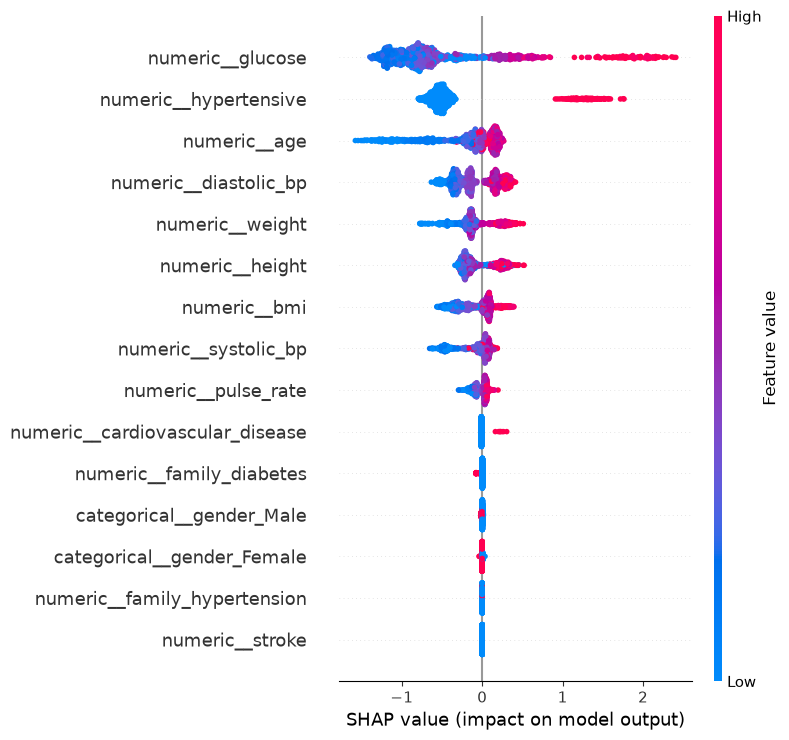

In [ ]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs("../reports/figures", exist_ok=True)

explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent",
)
shap_values = explainer.shap_values(X_test_transformed)
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=(
        explainer.expected_value
        if np.isscalar(explainer.expected_value)
        else explainer.expected_value[1]
    ),
    data=X_test_transformed,
    feature_names=feature_names,
)

shap.summary_plot(
    shap_explanation,
    show=False,
)
plt.savefig("../reports/figures/shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

#### Bar importance + saved ranking table

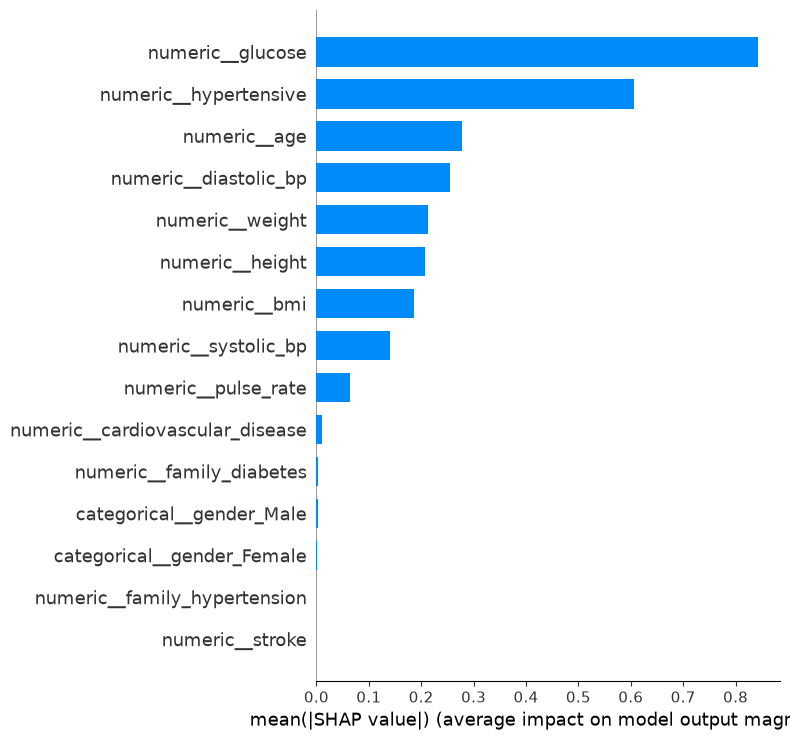

,feature,mean_abs_shap
4,numeric__glucose,0.842562
9,numeric__hypertensive,0.606475
0,numeric__age,0.277881
3,numeric__diastolic_bp,0.255874
6,numeric__weight,0.213390
5,numeric__height,0.207521
7,numeric__bmi,0.185409
2,numeric__systolic_bp,0.141132
1,numeric__pulse_rate,0.064796
11,numeric__cardiovascular_disease,0.011385


In [9]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar", show=False)
plt.savefig("../reports/figures/shap_bar_importance.png", dpi=150, bbox_inches="tight")
plt.show()

shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_array).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

os.makedirs("../reports/metrics", exist_ok=True)
importance_df.to_csv("../reports/metrics/shap_feature_importance.csv", index=False)
importance_df

#### Local explanation for one patient

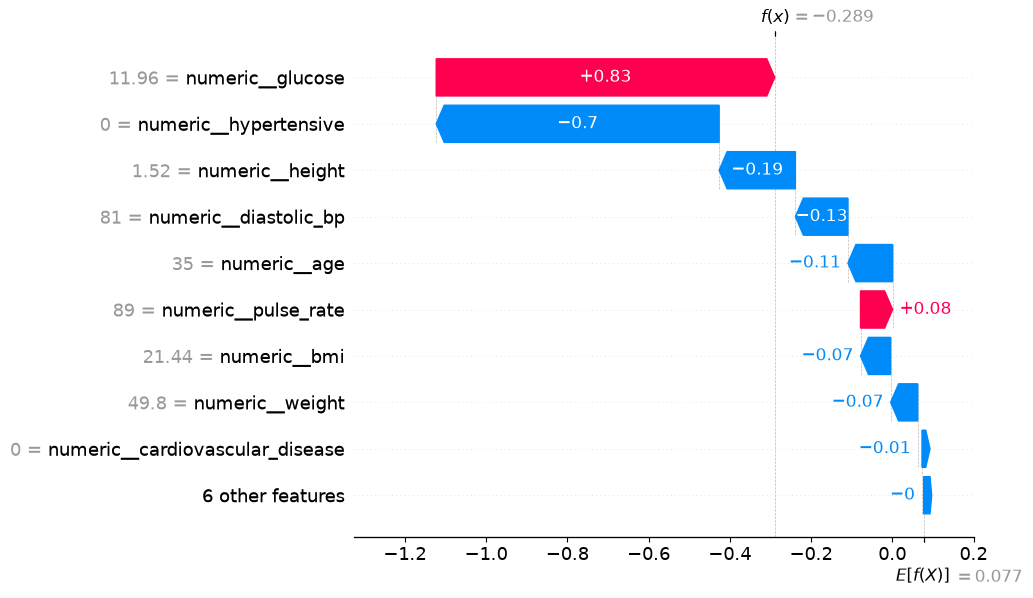

Actual label: 0 | Predicted prob: 0.4281579


In [12]:
idx = 0

base_value = (
    explainer.expected_value
    if np.isscalar(explainer.expected_value)
    else explainer.expected_value[1]
)

sample_explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=base_value,
    data=X_test_transformed[idx],
    feature_names=feature_names,
)

shap.plots.waterfall(sample_explanation, show=False)
plt.savefig("../reports/figures/shap_waterfall_sample.png", dpi=150, bbox_inches="tight")
plt.show()

print("Actual label:", y_test.iloc[idx], "| Predicted prob:", y_prob[idx])

#### Dependence plot for the top feature

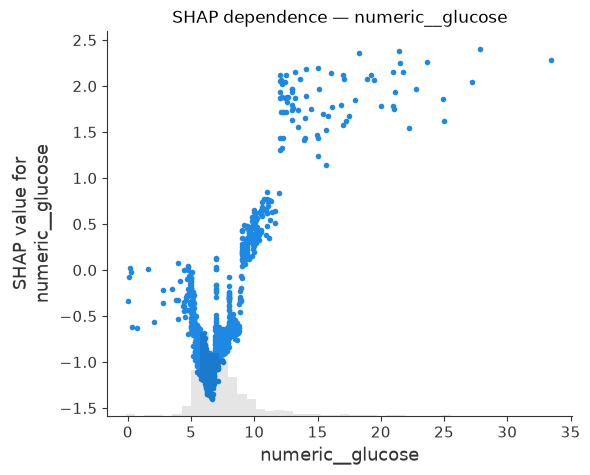

In [18]:
top_feature = importance_df.iloc[0]["feature"]
feature_idx = feature_names.tolist().index(top_feature)

if "shap_explanation" not in globals():
    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent",
    )
    shap_values = explainer.shap_values(X_test_transformed)
    shap_explanation = shap.Explanation(
        values=shap_values,
        base_values=(
            explainer.expected_value
            if np.isscalar(explainer.expected_value)
            else explainer.expected_value[1]
        ),
        data=X_test_transformed,
        feature_names=feature_names,
    )

shap.plots.scatter(shap_explanation[:, feature_idx], show=False)
plt.title(f"SHAP dependence — {top_feature}")
plt.savefig(
    f"../reports/figures/shap_dependence_{top_feature.split('__')[-1]}.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()